# Goal-Oriented Process Alignment for TUE Reimbursement


This notebook is organized to explain the paper method step by step. It uses the TUE domestic travel reimbursement case study to show how **Goal-Oriented Conformance Checking via Alignments (GoCCvA)** enriches standard process alignments with target-specific goal information.

The central question is:

> When an observed process execution fits or deviates from the process model, what does that mean for the selected stakeholder goals?

The notebook separates:

- **Inputs**: goal model, Petri net, event mapping, event log, selected targets.
- **Main computation**: process alignments enriched into goal-oriented alignments.
- **Numbers for the paper**: log statistics, diagnostic classes, divergence between behavioral conformance and goal fulfillment.
- **Visual explanation**: concrete rendered goal-oriented alignment examples.


## 1. Setup

This cell imports the libraries used throughout the notebook. Later cells use explicit variable names such as `full_summary` and `representative_summary` so that paper-level results are not accidentally overwritten by smaller examples.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))


In [2]:
from collections import Counter, defaultdict
from pathlib import Path
from pprint import pp
from statistics import mean, median

import pandas as pd
import pm4py
from IPython.display import Image, Markdown, display
from pm4py.objects.conversion.log import converter as log_converter

from Semantics.parsers.event_mapping_from_csv import read_event_mapping_csv
from Semantics.goccva.filter import ComplianceStatus, TraceFilter
from Semantics.goccva.helpers import sequences_to_event_log
from Semantics.goccva.pipeline import analyse
from Semantics.parsers.istar_processor import read_istar_model
from Semantics.parsers.petri_net_processor import read_petri_net
from Ui.goccva_ui import render_case_distribution_matrix, render_from_analysis

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 100)


## 2. Case Study Inputs

The paper instantiates GoCCvA on the BPI Challenge 2020 domestic travel reimbursement process. The four required inputs are:

1. a **goal model** with actors, goals, tasks, qualities, and dependencies;
2. a **process model** represented as a Petri net;
3. an **event mapping** from process activities to goal-model tasks;
4. an **event log** of observed reimbursement declarations.


In [3]:
base_path = Path("content/TUEReimbursement")
paths = {
    "goal_model": base_path / "gm.txt",
    "process_model": base_path / "pm.pnml",
    "event_mapping": base_path / "mapping.csv",
    "event_log": base_path / "DomesticDeclarations.xes.gz",
    "goal_model_image": base_path / "gm.png",
    "process_model_image": base_path / "pm.svg",
}

pd.DataFrame(
    [{"input": name, "path": str(path), "exists": path.exists()} for name, path in paths.items()]
)


,input,path,exists
0,goal_model,content/TUEReimbursement/gm.txt,True
1,process_model,content/TUEReimbursement/pm.pnml,True
2,event_mapping,content/TUEReimbursement/mapping.csv,True
3,event_log,content/TUEReimbursement/DomesticDeclarations.xes.gz,True
4,goal_model_image,content/TUEReimbursement/gm.png,True
5,process_model_image,content/TUEReimbursement/pm.svg,True


### 2.1 Load Models and Mapping

The activity mapping is canonicalized against the goal model to remove small naming inconsistencies such as spacing or parenthesis differences.


In [4]:
goal_model = read_istar_model(str(paths["goal_model"]), qualified=True)
petri_net = read_petri_net(str(paths["process_model"]))
activity_mapping = read_event_mapping_csv(str(paths["event_mapping"]))
activity_mapping = goal_model.canonicalize_activity_mapping(activity_mapping)

pd.DataFrame(
    [
        {"object": "goal_model", "status": "loaded"},
        {"object": "petri_net", "status": "loaded"},
        {"object": "activity_mapping", "status": f"{len(activity_mapping)} mapped activities"},
    ]
)


,object,status
0,goal_model,loaded
1,petri_net,loaded
2,activity_mapping,15 mapped activities


### 2.2 Visual Inputs

These are the two model artefacts used in the reimbursement case study.


**Goal model**

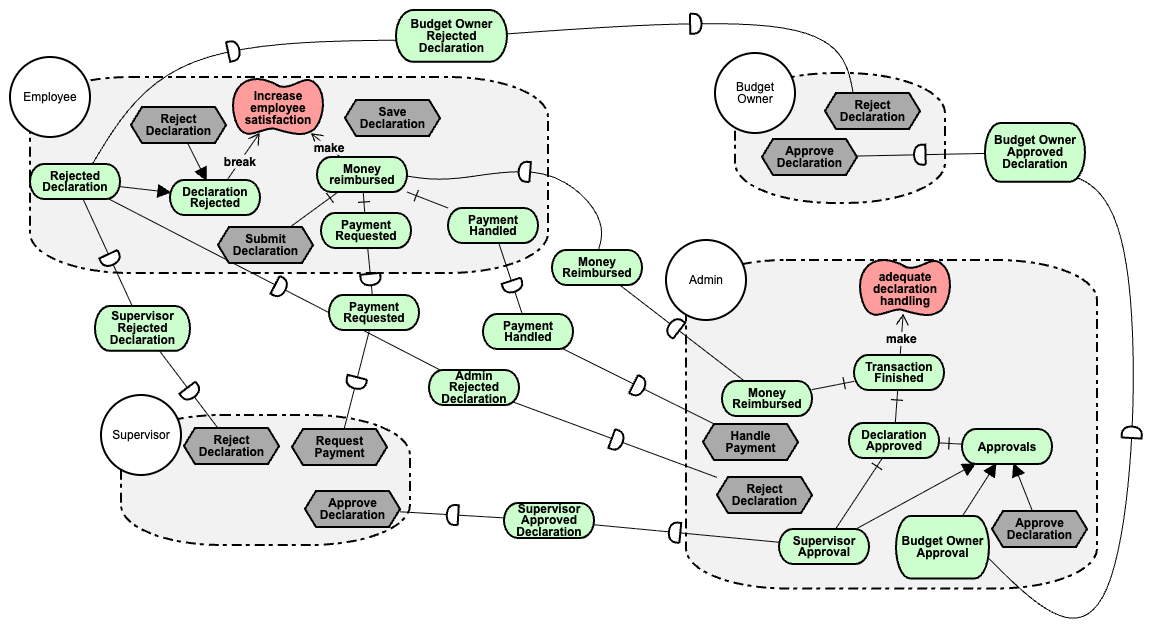

**Process model**

![Domestic declaration Petri net](content/TUEReimbursement/pm.svg)

In [5]:
display(Markdown("**Goal model**"))
display(Image(filename=str(paths["goal_model_image"])))

display(Markdown("**Process model**"))
display(Markdown(f"![Domestic declaration Petri net]({paths['process_model_image'].as_posix()})"))


## 3. Selected Targets

GoCCvA is target-specific. The same activity can support one selected target while being unrelated to another. Here the analysis evaluates one administration-oriented target and one employee-oriented target.


In [6]:
targets = [
    "(Admin) adequate declaration handling",
    "(Employee) Increase employee satisfaction",
]

pd.DataFrame({"target": targets})


,target
0,(Admin) adequate declaration handling
1,(Employee) Increase employee satisfaction


## 4. Activity Abbreviations

Short labels make the rendered goal-oriented alignments readable. The full activity names are kept in the data; these abbreviations are only used for display.


In [7]:
activity_abbreviations = {
    "Declaration REJECTED by ADMINISTRATION": "ra",
    "Payment Handled": "ph",
    "Declaration REJECTED by BUDGET OWNER": "rb",
    "Declaration SAVED by EMPLOYEE": "dsv",
    "Declaration APPROVED by ADMINISTRATION": "aa",
    "Declaration REJECTED by EMPLOYEE": "er",
    "Request Payment": "rp",
    "Declaration SUBMITTED by EMPLOYEE": "ds",
    "Declaration APPROVED by BUDGET OWNER": "ba",
    "Declaration FINAL_APPROVED by SUPERVISOR": "as",
    "Declaration REJECTED by SUPERVISOR": "rs",
    "Declaration APPROVED by PRE_APPROVER": "pa",
    "Declaration REJECTED by PRE_APPROVER": "rpa",
    "Declaration REJECTED by MISSING": "rm",
    "t_tau_rev": "tau",
}

pd.DataFrame(
    sorted(activity_abbreviations.items()),
    columns=["activity", "abbreviation"],
)


,activity,abbreviation
0,Declaration APPROVED by ADMINISTRATION,aa
1,Declaration APPROVED by BUDGET OWNER,ba
2,Declaration APPROVED by PRE_APPROVER,pa
3,Declaration FINAL_APPROVED by SUPERVISOR,as
4,Declaration REJECTED by ADMINISTRATION,ra
5,Declaration REJECTED by BUDGET OWNER,rb
6,Declaration REJECTED by EMPLOYEE,er
7,Declaration REJECTED by MISSING,rm
8,Declaration REJECTED by PRE_APPROVER,rpa
9,Declaration REJECTED by SUPERVISOR,rs


## 5. Load Event Log

The log is loaded once and then reused. The PM4Py parser may emit progress bars or timestamp warnings depending on the local environment; those messages are not part of the analytical result.


In [8]:
full_log = log_converter.apply(
    pm4py.read_xes(str(paths["event_log"])),
    variant=log_converter.Variants.TO_EVENT_LOG,
)

traces = [[event["concept:name"] for event in trace] for trace in full_log]

pd.DataFrame([{"loaded_cases": len(traces)}])


/Users/huba/miniconda3/envs/kogi/lib/python3.11/site-packages/pm4py/utils.py:987: UserWarning: In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.
  warnings.warn("In the current version, the import/export operation uses `rustxes` by default for importing/exporting files faster. Please uninstall `rustxes` to revert the behavior.")


,loaded_cases
0,10357


## 6. Descriptive Log Statistics

These are the descriptive numbers used to characterize the reimbursement log in the paper. A rejection case contains an activity whose name includes `REJECTED`. A resubmission case contains `Declaration SUBMITTED by EMPLOYEE` more than once.


In [9]:
case_count = len(traces)
event_count = sum(len(trace) for trace in traces)
activity_classes = sorted({activity for trace in traces for activity in trace})
variants = Counter(tuple(trace) for trace in traces)

payment_activity = "Payment Handled"
submission_activity = "Declaration SUBMITTED by EMPLOYEE"
rejection_activities = [activity for activity in activity_classes if "REJECTED" in activity]

cases_with_payment = sum(payment_activity in trace for trace in traces)
cases_with_rejection = sum(any(activity in rejection_activities for activity in trace) for trace in traces)
cases_with_resubmission = sum(trace.count(submission_activity) > 1 for trace in traces)
rejected_cases_with_payment = sum(
    any(activity in rejection_activities for activity in trace) and payment_activity in trace
    for trace in traces
)

log_statistics = pd.DataFrame(
    [
        {"measure": "events", "value": event_count, "percentage": None},
        {"measure": "cases", "value": case_count, "percentage": None},
        {"measure": "activity classes", "value": len(activity_classes), "percentage": None},
        {"measure": "trace variants", "value": len(variants), "percentage": None},
        {"measure": "cases with payment", "value": cases_with_payment, "percentage": cases_with_payment / case_count * 100},
        {"measure": "cases with rejection", "value": cases_with_rejection, "percentage": cases_with_rejection / case_count * 100},
        {"measure": "cases with resubmission", "value": cases_with_resubmission, "percentage": cases_with_resubmission / case_count * 100},
        {
            "measure": "rejected cases with payment",
            "value": rejected_cases_with_payment,
            "percentage": rejected_cases_with_payment / cases_with_rejection * 100,
        },
    ]
)

log_statistics["percentage"] = log_statistics["percentage"].map(lambda x: None if pd.isna(x) else round(x, 1))
log_statistics


,measure,value,percentage
0,events,55628,NaN
1,cases,10357,NaN
2,activity classes,14,NaN
3,trace variants,90,NaN
4,cases with payment,9912,95.7
5,cases with rejection,1278,12.3
6,cases with resubmission,1006,9.7
7,rejected cases with payment,967,75.7


## 7. Main GoCCvA Analysis

This is the main computation. It aligns each log trace with the Petri net and then enriches each alignment with target-specific goal information.

The result has three parts:

- `full_summary`: one row per analyzed trace, with process-alignment class and goal-fulfillment class;
- `full_detailed`: step-by-step goal-oriented alignments;
- `full_contribution_to_targets`: make, break, and non-related sets for each selected target.


In [10]:
full_summary, full_detailed, full_contribution_to_targets = analyse(
    goal_model,
    petri_net,
    full_log,
    targets,
    activity_mapping,
    initial_marking=None,
)

pd.DataFrame(full_summary).head()


aligning log, completed variants ::   0%|          | 0/90 [00:00<?, ?it/s]

,trace_id,trace,alignment_cost,fitness,traditional_class,goal_class
0,2222,Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration APPROVED by BUDGET OWNER | Declaration FINAL_AP...,0,1.0,optimal,Strongly compliant
1,2243,Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration APPROVED by BUDGET OWNER | Declaration FINAL_AP...,0,1.0,optimal,Strongly compliant
2,2253,Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration APPROVED by BUDGET OWNER | Declaration FINAL_AP...,0,1.0,optimal,Strongly compliant
3,2257,Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration APPROVED by BUDGET OWNER | Declaration FINAL_AP...,0,1.0,optimal,Strongly compliant
4,2258,Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration APPROVED by BUDGET OWNER | Declaration FINAL_AP...,0,1.0,optimal,Strongly compliant


### 7.1 Case Distribution Matrix

The six classes combine process-alignment quality with goal fulfillment:

- `O`: optimal alignment;
- `N`: non-optimal alignment;
- `+`: strongly fulfilled targets;
- `~`: weakly fulfilled targets;
- `-`: non-fulfilled targets.


In [11]:
full_matrix_result = render_case_distribution_matrix(
    summary=full_summary,
    title="TUE Reimbursement Case Distribution Matrix",
    targets=targets,
)

pd.DataFrame(
    [{"class": key, "cases": value} for key, value in full_matrix_result["counts"].items()]
)


,class,cases
0,O+,2411
1,O~,0
2,O-,185
3,N+,6584
4,N~,914
5,N-,263


## 8. Diagnostic Evidence For The Paper Discussion

This section reformats the main numbers into compact tables. The point is to make the paper claim explicit: **behavioral conformance and target fulfillment are related, but they are not the same thing**.


In [12]:
def goal_bucket(row):
    value = str(row.get("goal_class", "")).lower()
    if "strong" in value:
        return "strong"
    if "weak" in value:
        return "weak"
    return "non"


def behavior_bucket(row):
    return "O" if str(row.get("traditional_class", "")).lower() == "optimal" else "N"


def diagnostic_class(row):
    return behavior_bucket(row) + {"strong": "+", "weak": "~", "non": "-"}[goal_bucket(row)]


def pct(part, whole):
    return round(part * 100 / whole, 1) if whole else 0.0


rows_by_id = {int(row["trace_id"]): row for row in full_summary}

features = []
for trace_id, trace in enumerate(traces, start=1):
    row = rows_by_id[trace_id]
    timestamps = [
        event.get("time:timestamp")
        for event in full_log[trace_id - 1]
        if event.get("time:timestamp") is not None
    ]
    duration_days = None
    if timestamps:
        duration_days = (max(timestamps) - min(timestamps)).total_seconds() / 86400

    rejection_count = sum(activity in rejection_activities for activity in trace)
    features.append(
        {
            "trace_id": trace_id,
            "diagnostic_class": diagnostic_class(row),
            "goal_bucket": goal_bucket(row),
            "behavior_bucket": behavior_bucket(row),
            "paid": payment_activity in trace,
            "rejection": rejection_count > 0,
            "rejection_count": rejection_count,
            "resubmission": trace.count(submission_activity) > 1,
            "duration_days": duration_days,
            "length": len(trace),
        }
    )

features_df = pd.DataFrame(features)
case_classes = Counter(features_df["diagnostic_class"])
behavior_classes = Counter(features_df["behavior_bucket"])

pd.DataFrame(
    [
        {"class": key, "cases": case_classes.get(key, 0), "percentage": pct(case_classes.get(key, 0), case_count)}
        for key in ["O+", "O~", "O-", "N+", "N~", "N-"]
    ]
)


,class,cases,percentage
0,O+,2411,23.3
1,O~,0,0.0
2,O-,185,1.8
3,N+,6584,63.6
4,N~,914,8.8
5,N-,263,2.5


In [13]:
optimal = behavior_classes["O"]
non_optimal = behavior_classes["N"]
optimal_non = case_classes["O-"]
non_optimal_fulfilled = case_classes["N+"] + case_classes["N~"]

pd.DataFrame(
    [
        {"claim": "optimal alignments", "cases": optimal, "percentage": pct(optimal, case_count)},
        {"claim": "non-optimal alignments", "cases": non_optimal, "percentage": pct(non_optimal, case_count)},
        {
            "claim": "optimal but non-fulfilled",
            "cases": optimal_non,
            "percentage": pct(optimal_non, optimal),
            "percentage_base": "of optimal cases",
        },
        {
            "claim": "non-optimal but fulfilled",
            "cases": non_optimal_fulfilled,
            "percentage": pct(non_optimal_fulfilled, non_optimal),
            "percentage_base": "of non-optimal cases",
        },
    ]
)


,claim,cases,percentage,percentage_base
0,optimal alignments,2596,25.1,NaN
1,non-optimal alignments,7761,74.9,NaN
2,optimal but non-fulfilled,185,7.1,of optimal cases
3,non-optimal but fulfilled,7498,96.6,of non-optimal cases


In [14]:
paid_by_goal = Counter(item["goal_bucket"] for item in features if item["paid"])
unpaid_by_goal = Counter(item["goal_bucket"] for item in features if not item["paid"])
rejected = [item for item in features if item["rejection"]]
resubmitted = [item for item in features if item["resubmission"]]
rejected_paid = [item for item in rejected if item["paid"]]

pd.DataFrame(
    [
        {"measure": "paid cases", "cases": sum(paid_by_goal.values()), "percentage": pct(sum(paid_by_goal.values()), case_count)},
        {"measure": "paid and strongly fulfilled", "cases": paid_by_goal.get("strong", 0), "percentage": None},
        {"measure": "paid and weakly fulfilled", "cases": paid_by_goal.get("weak", 0), "percentage": None},
        {"measure": "paid but non-fulfilled", "cases": paid_by_goal.get("non", 0), "percentage": None},
        {"measure": "unpaid and non-fulfilled", "cases": unpaid_by_goal.get("non", 0), "percentage": None},
        {"measure": "rejected cases", "cases": len(rejected), "percentage": pct(len(rejected), case_count)},
        {"measure": "rejected and paid", "cases": len(rejected_paid), "percentage": pct(len(rejected_paid), len(rejected))},
        {"measure": "resubmission cases", "cases": len(resubmitted), "percentage": pct(len(resubmitted), case_count)},
    ]
)


,measure,cases,percentage
0,paid cases,9912,95.7
1,paid and strongly fulfilled,8995,NaN
2,paid and weakly fulfilled,914,NaN
3,paid but non-fulfilled,3,NaN
4,unpaid and non-fulfilled,445,NaN
5,rejected cases,1278,12.3
6,rejected and paid,967,75.7
7,resubmission cases,1006,9.7


In [15]:
def stats(values):
    values = list(values)
    if not values:
        return {"n": 0, "median": None, "mean": None}
    return {"n": len(values), "median": round(median(values), 2), "mean": round(mean(values), 2)}

summary_rows = []
for key in ["strong", "weak", "non"]:
    duration_stats = stats(
        item["duration_days"]
        for item in features
        if item["goal_bucket"] == key and item["duration_days"] is not None
    )
    length_stats = stats(item["length"] for item in features if item["goal_bucket"] == key)
    summary_rows.append(
        {
            "goal_fulfillment": key,
            "cases": duration_stats["n"],
            "duration_median_days": duration_stats["median"],
            "duration_mean_days": duration_stats["mean"],
            "trace_length_median": length_stats["median"],
            "trace_length_mean": length_stats["mean"],
        }
    )

pd.DataFrame(summary_rows)


,goal_fulfillment,cases,duration_median_days,duration_mean_days,trace_length_median,trace_length_mean
0,strong,8995,7.26,10.13,5.0,5.13
1,weak,914,13.14,22.02,9.0,8.99
2,non,448,0.71,8.02,3.0,2.87


### 8.1 Why Target-Specific Labels Matter

The following evidence checks whether traces contain a `B` label for employee satisfaction. This is important because rejections are interpreted as breaking employee satisfaction, even if they can be non-related for adequate declaration handling.


In [16]:
labels_per_trace_target = defaultdict(lambda: defaultdict(set))
for item in full_detailed:
    trace_id = int(item["trace_id"])
    for step in item.get("goal_oriented_alignment", []):
        for theta in step.get("theta", []):
            labels_per_trace_target[trace_id][theta["target"]].add(theta["label"])

satisfaction_target = "(Employee) Increase employee satisfaction"
weak_trace_ids = [item["trace_id"] for item in features if item["goal_bucket"] == "weak"]
strong_trace_ids = [item["trace_id"] for item in features if item["goal_bucket"] == "strong"]
non_trace_ids = [item["trace_id"] for item in features if item["goal_bucket"] == "non"]

pd.DataFrame(
    [
        {
            "goal_fulfillment": "weak",
            "cases_with_B_for_employee_satisfaction": sum(
                "B" in labels_per_trace_target[trace_id][satisfaction_target]
                for trace_id in weak_trace_ids
            ),
            "total_cases": len(weak_trace_ids),
        },
        {
            "goal_fulfillment": "strong",
            "cases_with_B_for_employee_satisfaction": sum(
                "B" in labels_per_trace_target[trace_id][satisfaction_target]
                for trace_id in strong_trace_ids
            ),
            "total_cases": len(strong_trace_ids),
        },
        {
            "goal_fulfillment": "non",
            "cases_with_B_for_employee_satisfaction": sum(
                "B" in labels_per_trace_target[trace_id][satisfaction_target]
                for trace_id in non_trace_ids
            ),
            "total_cases": len(non_trace_ids),
        },
    ]
)


,goal_fulfillment,cases_with_B_for_employee_satisfaction,total_cases
0,weak,914,914
1,strong,0,8995
2,non,444,448


## 9. Target Contribution Sets

The make, break, and non-related sets explain why each activity receives a target-specific label. These sets are computed from the loaded goal model for the selected targets.


In [17]:
pd.DataFrame(full_contribution_to_targets)


,target,MakeSet,BreakSet,NRSet
0,(Admin) adequate declaration handling,"(Admin) Approve Declaration, (Admin) Handle Payment, (Budget Owner) Approve Declaration, (Employee) Submit Declaration, (Supervisor) App...",,"(Admin) Reject Declaration, (Budget Owner) Reject Declaration, (Employee) Reject Declaration, (Employee) Save Declaration, (Supervisor) ..."
1,(Employee) Increase employee satisfaction,"(Admin) Handle Payment, (Employee) Submit Declaration, (Supervisor) Request Payment","(Admin) Reject Declaration, (Budget Owner) Reject Declaration, (Employee) Reject Declaration, (Supervisor) Reject Declaration","(Admin) Approve Declaration, (Budget Owner) Approve Declaration, (Employee) Save Declaration, (Supervisor) Approve Declaration"


## 10. Rendered Goal-Oriented Alignment Example

This section renders one concrete alignment instead of only reporting aggregate numbers. The example trace is:

`Declaration SUBMITTED by EMPLOYEE -> Declaration FINAL_APPROVED by SUPERVISOR -> Request Payment -> Payment Handled`

It is useful for reviewers because it shows a **non-optimal alignment** that is nevertheless **strongly fulfilled** with respect to the selected targets.


In [18]:
representative_trace = [[
    "Declaration SUBMITTED by EMPLOYEE",
    "Declaration FINAL_APPROVED by SUPERVISOR",
    "Request Payment",
    "Payment Handled",
]]

representative_summary, representative_detailed, representative_contribution = analyse(
    goal_model,
    petri_net,
    sequences_to_event_log(representative_trace),
    targets,
    activity_mapping,
    initial_marking=None,
)

pd.DataFrame(representative_summary)


,trace_id,trace,alignment_cost,fitness,traditional_class,goal_class
0,1,Declaration SUBMITTED by EMPLOYEE | Declaration FINAL_APPROVED by SUPERVISOR | Request Payment | Payment Handled,20000,0.714286,non-optimal,Strongly compliant


In [19]:
render_from_analysis(
    activity_abbreviations=activity_abbreviations,
    summary=representative_summary,
    detailed=representative_detailed,
    contribution_to_targets=representative_contribution,
    title="Rendered Goal-Oriented Alignment Example",
)


# Rendered Goal-Oriented Alignment Example

The following cases illustrate combinations of alignment class and target-fulfilment class. Each table separates the process alignment row from the target-specific interpretation rows.

The rendered alignment should be read row by row:

- the `log` and `model` rows show the process alignment;
- the target rows show `M`, `B`, `NR`, or `ND` labels for each selected target;
- the marking rows show the target status reached after each aligned move.

The key interpretation is that missing model-side approvals make the process alignment non-optimal, but the selected goals still become satisfied by the end of the execution.


## 11. Frequent Trace Variants

The full event log contains many repeated traces. This section analyzes unique variants ordered by frequency, then renders the three most frequent variants as goal-oriented alignments.


In [20]:
traces_by_frequency = Counter(tuple(trace) for trace in traces)
most_used_traces_by_frequency = traces_by_frequency.most_common(10)

pd.DataFrame(
    [
        {"rank": index, "frequency": count, "trace": " -> ".join(trace)}
        for index, (trace, count) in enumerate(most_used_traces_by_frequency, start=1)
    ]
)


,rank,frequency,trace
0,1,4566,Declaration SUBMITTED by EMPLOYEE -> Declaration APPROVED by ADMINISTRATION -> Declaration FINAL_APPROVED by SUPERVISOR -> Request Payme...
1,2,2411,Declaration SUBMITTED by EMPLOYEE -> Declaration APPROVED by ADMINISTRATION -> Declaration APPROVED by BUDGET OWNER -> Declaration FINAL...
2,3,1392,Declaration SUBMITTED by EMPLOYEE -> Declaration FINAL_APPROVED by SUPERVISOR -> Request Payment -> Payment Handled
3,4,575,Declaration SUBMITTED by EMPLOYEE -> Declaration APPROVED by PRE_APPROVER -> Declaration FINAL_APPROVED by SUPERVISOR -> Request Payment...
4,5,342,Declaration SUBMITTED by EMPLOYEE -> Declaration REJECTED by ADMINISTRATION -> Declaration REJECTED by EMPLOYEE -> Declaration SUBMITTED...
5,6,183,Declaration SUBMITTED by EMPLOYEE -> Declaration REJECTED by ADMINISTRATION -> Declaration REJECTED by EMPLOYEE -> Declaration SUBMITTED...
6,7,174,Declaration SUBMITTED by EMPLOYEE -> Declaration REJECTED by ADMINISTRATION -> Declaration REJECTED by EMPLOYEE
7,8,134,Declaration SAVED by EMPLOYEE
8,9,77,Declaration SUBMITTED by EMPLOYEE -> Declaration APPROVED by ADMINISTRATION -> Declaration REJECTED by SUPERVISOR -> Declaration REJECTE...
9,10,57,Declaration SUBMITTED by EMPLOYEE -> Declaration REJECTED by PRE_APPROVER -> Declaration REJECTED by EMPLOYEE -> Declaration SUBMITTED b...


In [21]:
most_used_traces_log = sequences_to_event_log(
    [list(trace) for trace, _ in traces_by_frequency.most_common(3)]
)

frequent_summary, frequent_detailed, frequent_contribution = analyse(
    goal_model,
    petri_net,
    most_used_traces_log,
    targets,
    activity_mapping,
    initial_marking=None,
)

render_from_analysis(
    activity_abbreviations=activity_abbreviations,
    summary=frequent_summary,
    detailed=frequent_detailed,
    contribution_to_targets=frequent_contribution,
    title="Goal-Oriented Alignments for the Three Most Frequent Variants",
)


aligning log, completed variants ::   0%|          | 0/3 [00:00<?, ?it/s]

# Goal-Oriented Alignments for the Three Most Frequent Variants

The following cases illustrate combinations of alignment class and target-fulfilment class. Each table separates the process alignment row from the target-specific interpretation rows.

## 12. Trace Query Examples

The trace filter is a lightweight way to inspect cases by goal fulfillment and activity content. These examples are included because they connect the aggregate results back to concrete executions.


In [22]:
trace_filter = TraceFilter(goal_model, traces, activity_mapping)

employee_satisfied_traces = (
    trace_filter
    .query()
    .where("(Employee) Increase employee satisfaction", ComplianceStatus.COMPLIANT)
    .traces()
)

adequate_declaration_traces = (
    trace_filter
    .query()
    .where("(Employee) Increase employee satisfaction", ComplianceStatus.COMPLIANT)
    .where("(Admin) adequate declaration handling", ComplianceStatus.COMPLIANT)
    .traces()
)

pd.DataFrame(
    [
        {
            "query": "employee satisfaction is strongly or weakly compliant",
            "matching_traces": len(employee_satisfied_traces),
            "percentage_of_log": round(len(employee_satisfied_traces) * 100 / len(traces), 2),
        },
        {
            "query": "employee satisfaction and adequate declaration handling are compliant",
            "matching_traces": len(adequate_declaration_traces),
            "percentage_of_employee_satisfied": round(len(adequate_declaration_traces) * 100 / len(employee_satisfied_traces), 2),
        },
    ]
)


,query,matching_traces,percentage_of_log,percentage_of_employee_satisfied
0,employee satisfaction is strongly or weakly compliant,9909,95.67,NaN
1,employee satisfaction and adequate declaration handling are compliant,9909,NaN,100.0


In [23]:
payment_but_no_declaration_submitted = (
    trace_filter
    .query()
    .contains("Payment Handled")
    .not_contains("Declaration SUBMITTED by EMPLOYEE")
    .sort_by_length()
    .traces()
)

no_satisfaction_but_paid = (
    trace_filter
    .query()
    .where("(Employee) Increase employee satisfaction", ComplianceStatus.NON_COMPLIANT)
    .contains("Payment Handled")
    .sort_by_length()
    .traces()
)

pd.DataFrame(
    [
        {
            "query": "payment handled but declaration was not submitted",
            "matching_traces": len(payment_but_no_declaration_submitted),
            "examples": payment_but_no_declaration_submitted[:3],
        },
        {
            "query": "payment handled but employee satisfaction is non-compliant",
            "matching_traces": len(no_satisfaction_but_paid),
            "examples": no_satisfaction_but_paid[:3],
        },
    ]
)


,query,matching_traces,examples
0,payment handled but declaration was not submitted,1,"[[Declaration SAVED by EMPLOYEE, Request Payment, Payment Handled]]"
1,payment handled but employee satisfaction is non-compliant,3,"[[Declaration SAVED by EMPLOYEE, Request Payment, Payment Handled], [Declaration SUBMITTED by EMPLOYEE, Declaration REJECTED by SUPERVIS..."


## 13. Optional Interactive Goal-Model Exploration

The widget below is optional. It is useful for local exploration, but it is not needed to reproduce the paper numbers. Run it only in a live Jupyter environment with widget support.


In [ ]:
# Optional interactive exploration. Uncomment to use in a live notebook.
# from Ui.interface import WhatIfInterfaceBuilder
# interface = WhatIfInterfaceBuilder(goal_model).create_interface()
# display(interface)
